![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

Badano ocenę poprawy jakości życia pacjentów z depresją po wprowadzeniu dwóch różnych leków. Zmienna rating określa samopoczucie pacjenta po pewnym czasie stosowania leków. Jedna grupa pacjentów przyjmowała Zoloft druga Desvenlafaxine. Zweryfikuj hipotezę, że Zoloft jest lekiem mniej skutecznym.

In [1]:
import scipy.stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Wczytanie danych dotyczących analizowanych leków na depresję

In [2]:
df = pd.read_csv("antidepressant_rating.csv") # import danych do obiektu DataFrame
print(df.columns) # wypisanie nazw kolumn
del df[df.columns[0]] # usunięcie zbędnej kolumny
df.head() # wypisanie kilku początkowych wierszy danych

Index(['Unnamed: 0', 'drugName', 'rating'], dtype='object')


,drugName,rating
0,Mirtazapine,10
1,Escitalopram,9
2,Zoloft,1
3,Effexor XR,1
4,Venlafaxine,8


**Wykonanie obliczeń**

In [3]:
x = df.loc[df["drugName"]=="Zoloft","rating"].values # pobranie wartości dotyczących leku Zoloft
y = df.loc[df["drugName"]=="Desvenlafaxine","rating"].values # pobranie wartości dotyczących leku Desvenlafaxine

**Wykonanie prostej analizy porównawczej**

Wykresy skrzynkowe

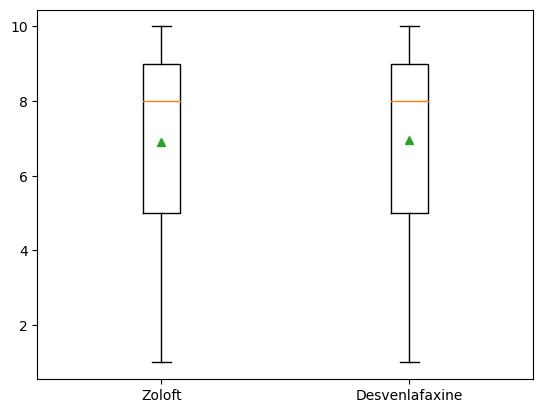

In [4]:
plt.boxplot([x, y],showmeans=True,labels = ["Zoloft","Desvenlafaxine"])
pass

Porównanie histogramów

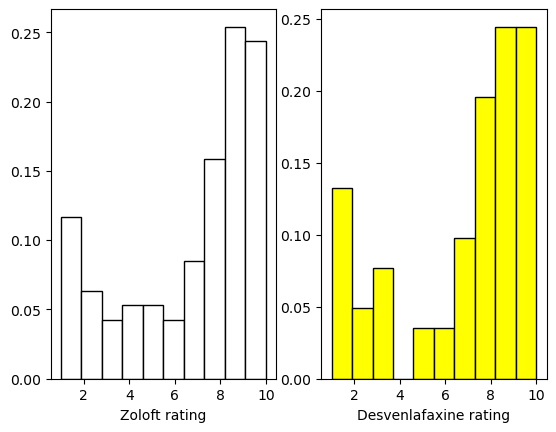

In [5]:
plt.subplot(1,2,1)
plt.hist(x,edgecolor = "black", color = "white", density= True)
plt.xlabel("Zoloft rating")
plt.subplot(1,2,2)
plt.hist(y,edgecolor = "black", color = "yellow",density= True)
plt.xlabel("Desvenlafaxine rating")
pass

Umieszczenie dwóch histogramów na jednym wykresie

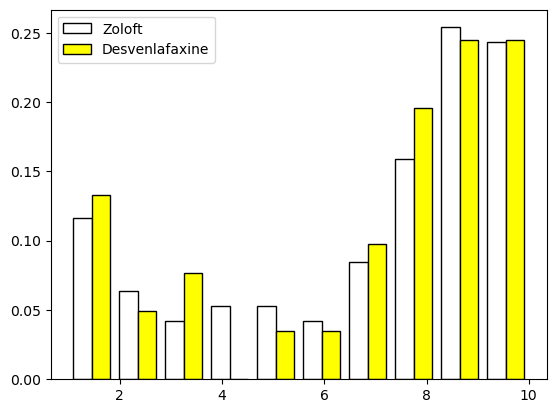

In [6]:
plt.hist([x,y],edgecolor = "black", color = ["white","yellow"], density= True)
plt.legend(["Zoloft","Desvenlafaxine"])
pass

**Przeprowadzenie testu.**

W tym teście nie ma założenia o równości wariancji dwóch populacji, zatem nie ma konieczności przeprowadzania najpierw testu dla równości wariancji.

W każdym teście należy określić wartość statystyki testowej i odpowiadającej jej p-wartości.

In [7]:
# Zoloft
nx = len(x)
mx = st.tmean(x)
sx = st.tstd(x)

# Desvenlafaxine
ny = len(y)
my = st.tmean(y)
sy = st.tstd(y)

a = 0.05 # z góry założony poziom istotności

u = (mx-my)/np.sqrt(sx**2/nx + sy**2/ny) # obliczenie statystyki testowej dla tego testu i tych spełnionych założeń.

rozkladNormalny = st.norm() # utworzenie instancji rozkładu normalnego
pvalue = rozkladNormalny.cdf(u) # hipoteza alternatywna lewostronna więc p-value liczy się od lewej strony
                                  # jest to po prostu wartość prawdopodobieństwa dla otrzymanej statystyki testowej
print("p-value={} jest {} niż poziom istotności {}.".format(pvalue,"większa" if pvalue>a else "mniejsza",a))
if pvalue>a:
    print("Brak podstaw do odrzucenia hipotezy zerowej: średnie są równe.")
else:
    print("Hipotezę zerową należy odrzucić na rzecz hipotezy alternatywnej: średnia mx jest mniejsza od my")

p-value=0.44476458051033546 jest większa niż poziom istotności 0.05.
Brak podstaw do odrzucenia hipotezy zerowej: średnie są równe.


#### Wykonanie obliczeń z użyciem testu z biblioteki scipy

In [8]:
# testowanie założenia o równości wariancji
lev_test = st.levene(x,y)
lev_test

LeveneResult(statistic=0.05533954662774359, pvalue=0.81420343696749)

In [9]:
if lev_test.pvalue > 0.05: # wariancje możemy uznać za równe
    is_var_equal = True
else:
    is_var_equal = False
    
st.ttest_ind(x,y,alternative="less",equal_var=is_var_equal)

Ttest_indResult(statistic=-0.138626486654527, pvalue=0.44492590090816)

Wykorzystanie testu permutacyjnego do obliczenia wartości p-value.

In [10]:
def statistic(x, y, axis=None):
    return np.mean(x)-np.mean(y)

st.permutation_test((x,y),statistic,alternative='less',n_resamples=250).pvalue

0.4581673306772908